In [1]:
from nrem_analysis.constant import PROCESSED_DIR, INTERIM_DIR
from pathlib import Path

import pynapple as nap
import numpy as np
import matplotlib.pyplot as plt

from cmap import Colormap
from matplotlib.colors import TwoSlopeNorm

cm = Colormap("colorbrewer:Set2")
norm = TwoSlopeNorm(vmin=-10, vcenter=0, vmax=10)

plt.rcParams.update({
    "figure.dpi":        150,
    "savefig.dpi":       320,
    "font.family":       "sans-serif",
    'font.sans-serif':   "Arial",
    "axes.grid":         False,
    "figure.constrained_layout.use": True,
})

def circdiff(x, y):
    return (x - y + 180) % 360 - 180

AWAKE_STA_KWARGS = dict(binsize=50, window=(-2000, 2000), time_unit="ms")
STATE_NAMES = ["continuous", "fragmented", "stationary"]
MOUSE_IDS = ["99b", "103c", "106b", "107b", "110b"]

def compute_circular_sta(angles, events, **kwargs):
    angles = np.deg2rad(angles)
    angles_cartesian = np.column_stack([np.sin(angles), np.cos(angles)]) # -> atan2(y, x)
    sta = nap.compute_event_triggered_average(
            angles_cartesian,
            events,
            **kwargs,
            )
    return nap.TsdFrame(
        t=sta.t,
        d=np.rad2deg(np.arctan2(sta[:, :, 0].d, sta[:, :, 1].d)),
    )

def compute_arithmetic_sta(angles, events, **kwargs):
    sta = nap.compute_event_triggered_average(
            np.unwrap(np.deg2rad(angles)),
            events,
            **kwargs,
            )
    return np.rad2deg(sta)

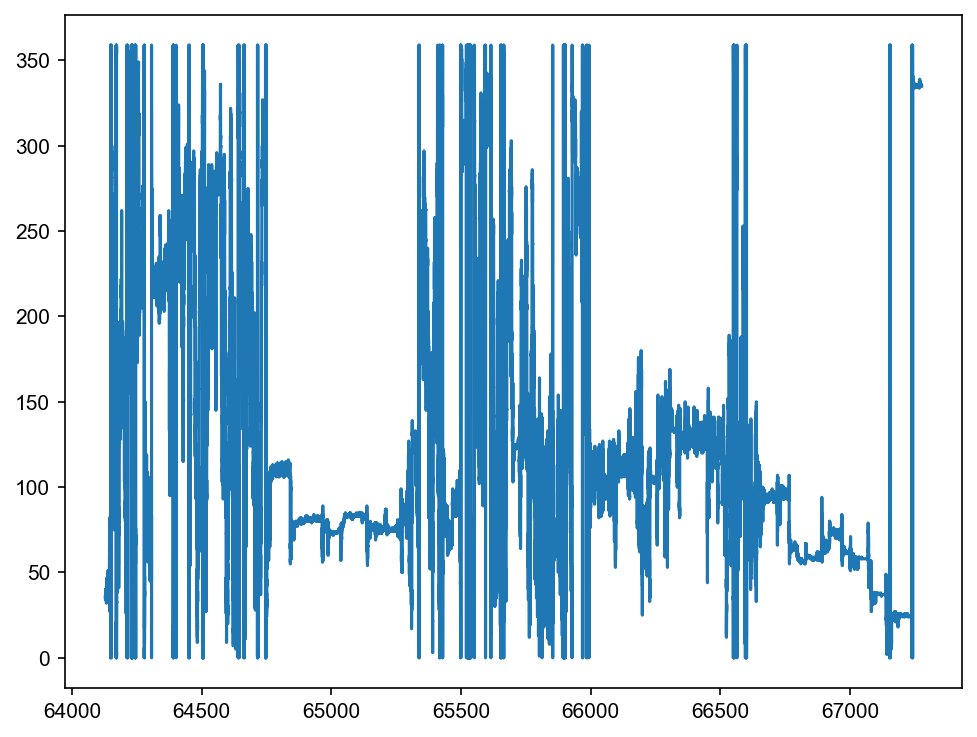

In [67]:
plt.plot(head_direction)

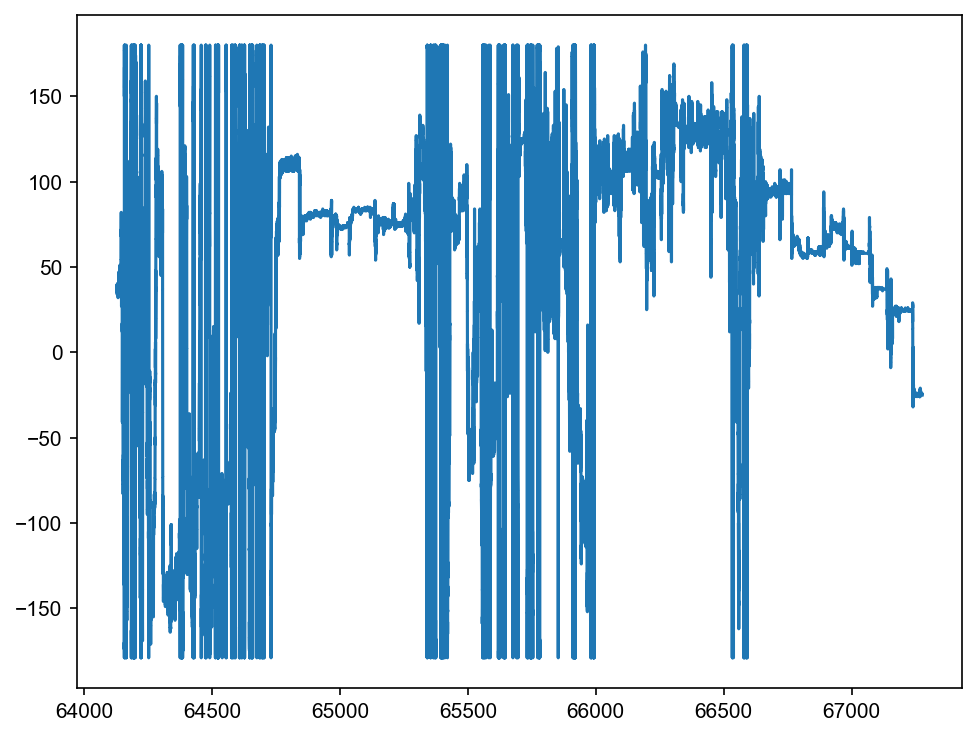

In [80]:
angles = np.deg2rad(head_direction.d)
data = np.arctan2(np.sin(angles), np.cos(angles))
data = np.rad2deg(data)
# data = (data + 180) % 360
plt.plot(head_direction.t, data)
plt.show()

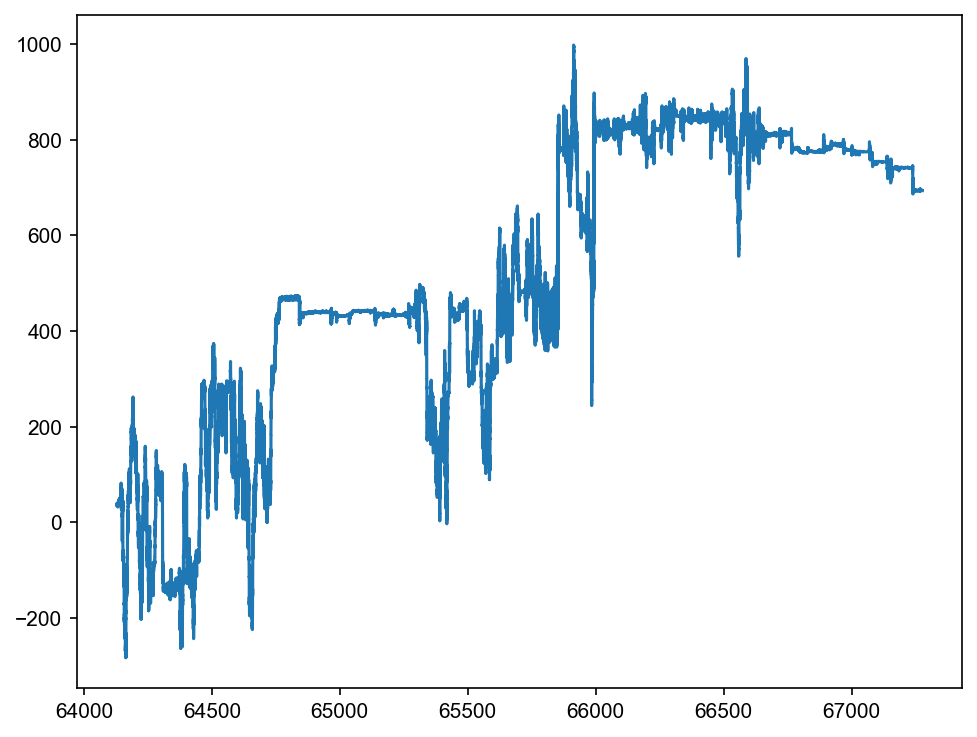

In [57]:
plt.plot(np.unwrap(head_direction))

In [ ]:
tsi = []
sta_circular = []
sta_mean = []

for mouse_id in MOUSE_IDS:
    turn_units      = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "turn_units.npz")
    head_direction  = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "head_direction.npz")

    tsi.append(turn_units['turn_index'].values)
    for compute, container in zip([compute_circular_sta, compute_arithmetic_sta], [sta_circular, sta_mean]):
        sta = compute(head_direction, turn_units, **AWAKE_STA_KWARGS)
        zero_idx = np.where(sta.index == 0)[0].item()
        baseline = sta[zero_idx, :]
        sta = circdiff(sta, baseline)
        container.append(sta)

tsi = np.concatenate(tsi)
sta_circular = np.column_stack(sta_circular)
sta_mean = np.column_stack(sta_mean)
order = np.argsort(tsi)

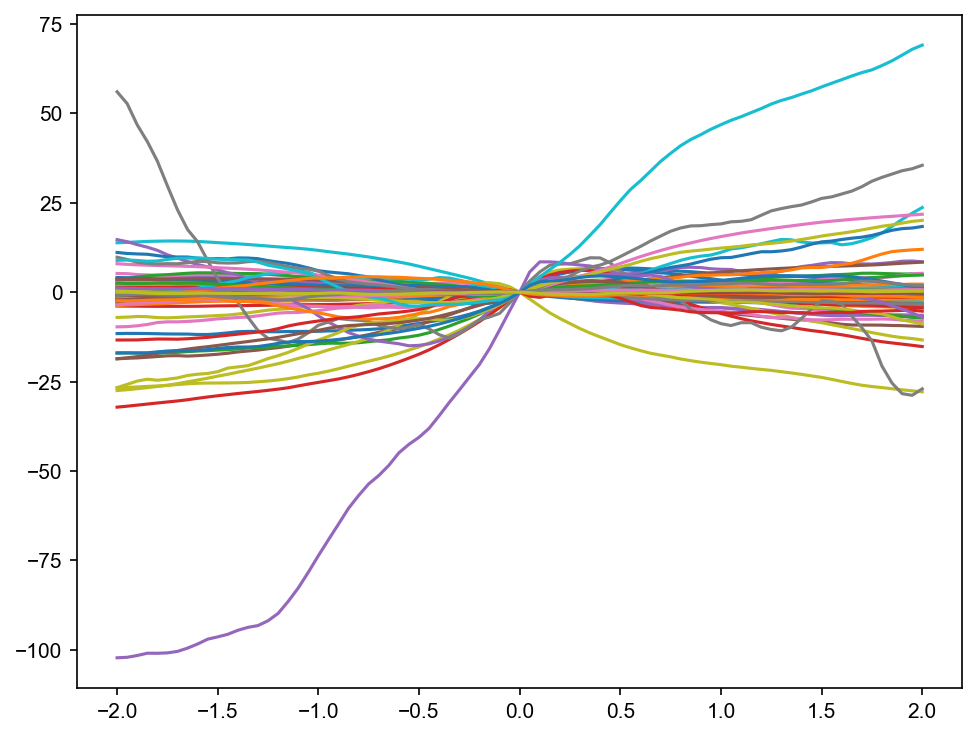

In [46]:
plt.plot(sta_circular)
plt.show()

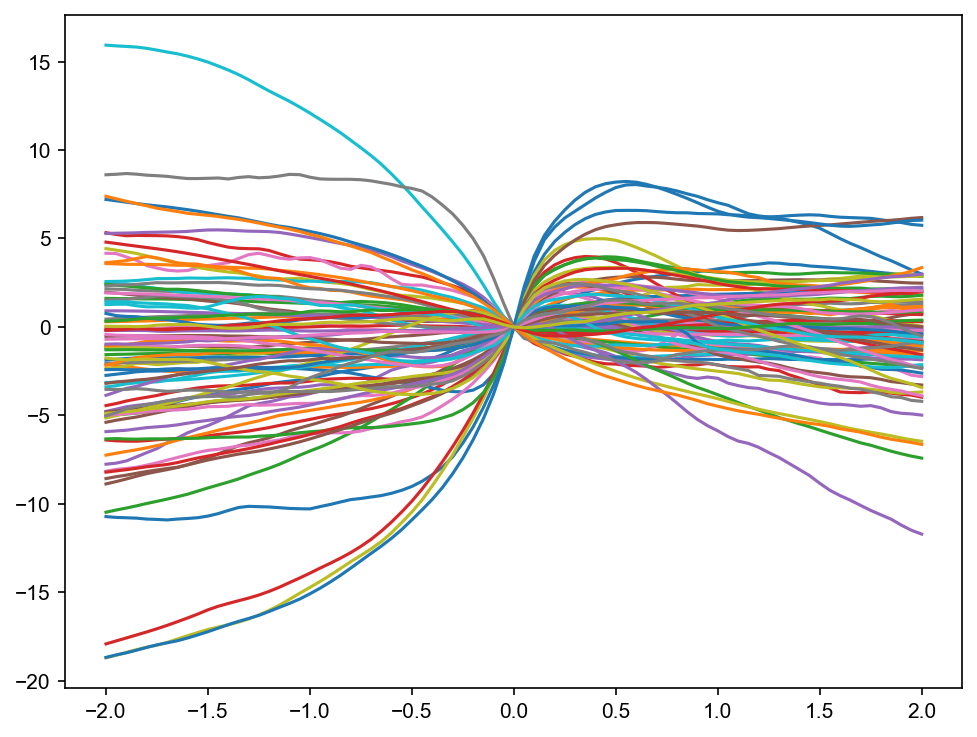

In [47]:
plt.plot(sta_mean)
plt.show()

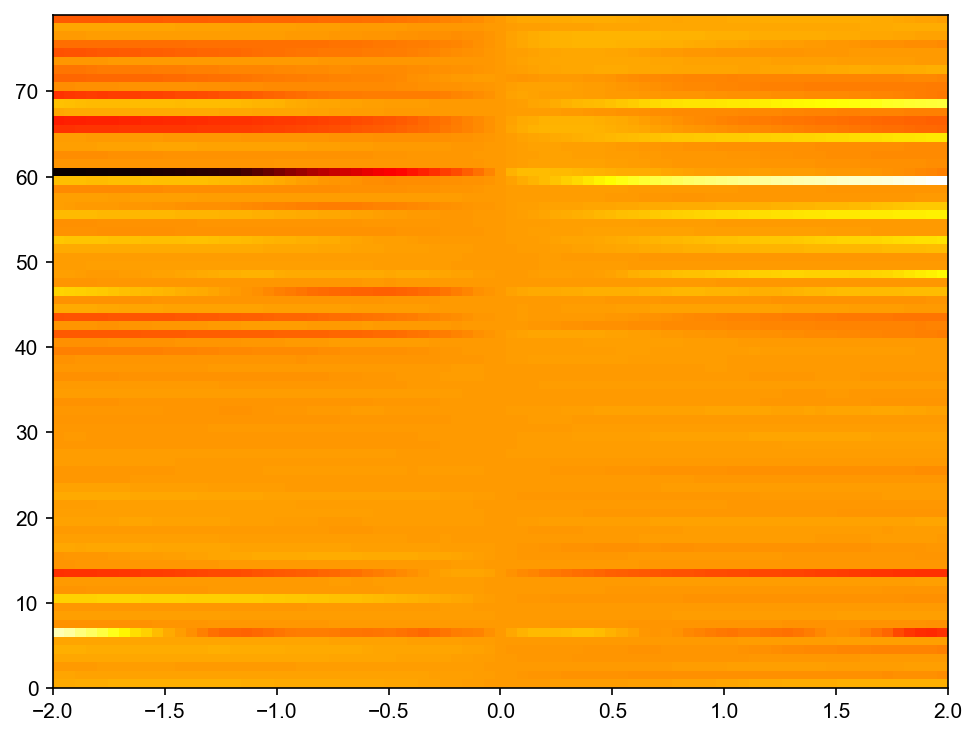

In [48]:
sta=sta_circular
plt.imshow(
    sta[:, order].d.T,
    aspect='auto',
    origin='lower',
    extent=[sta.index[0], sta.index[-1], 0, sta.shape[1]],
    cmap='hot',
    # norm=norm,
    )

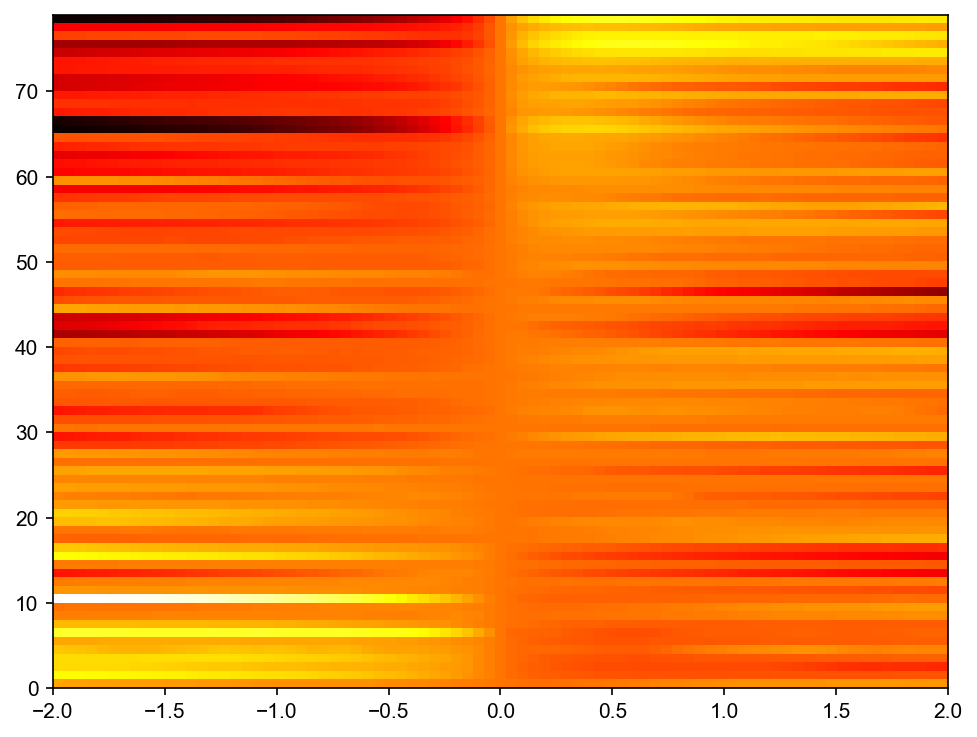

In [49]:
sta=sta_mean
plt.imshow(
    sta[:, order].d.T,
    aspect='auto',
    origin='lower',
    extent=[sta.index[0], sta.index[-1], 0, sta.shape[1]],
    cmap='hot',
    # norm=norm,
    )

In [5]:
import numpy as np
import pynapple as nap


def compute_unwrapped_sta(
    angles,
    events,
    binsize=50,
    window=(-2000, 2000),
    time_unit="ms",
    batch_size=1000,
):
    scale = {"s": 1.0, "ms": 1e-3, "us": 1e-6}[time_unit]

    valid_ep = nap.IntervalSet(
        start=angles.time_support.start + abs(window[0]) * scale,
        end=angles.time_support.end - abs(window[1]) * scale,
    )

    unit_stas = []
    unit_ids = list(events.index)

    for unit_id in unit_ids:
        unit_events = events[unit_id].restrict(valid_ep)
        event_times = unit_events.t

        total = None
        n_events = 0
        relative_time = None
        relative_support = None

        for start in range(0, len(event_times), batch_size):
            batch_times = event_times[start : start + batch_size]

            batch_events = nap.Ts(
                t=batch_times,
                time_support=valid_ep,
            )

            aligned = nap.compute_perievent(
                data=angles,
                events=batch_events,
                window=window,
                time_unit=time_unit,
                epochs=valid_ep,
            )

            # Shape: relative time × events
            x = np.unwrap(
                np.deg2rad(aligned.values),
                axis=0,
            )

            zero_idx = np.argmin(np.abs(aligned.t))

            # Baseline-normalize each event.
            x -= x[zero_idx, :]

            if total is None:
                total = np.zeros(x.shape[0])
                relative_time = aligned.t
                relative_support = aligned.time_support

            total += np.sum(x, axis=1)
            n_events += x.shape[1]

        mean_displacement = np.rad2deg(total / n_events)

        mean_displacement = nap.Tsd(
            t=relative_time,
            d=mean_displacement,
            time_support=relative_support,
        ).bin_average(
            binsize,
            time_units=time_unit,
        )

        unit_stas.append(mean_displacement.values)

    return nap.TsdFrame(
        t=mean_displacement.t,
        d=np.column_stack(unit_stas),
        columns=unit_ids,
    )

In [ ]:
tsi = []
sta = []
for mouse_id in MOUSE_IDS:
    turn_units      = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "turn_units.npz")
    head_direction  = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "head_direction.npz")

    tsi.append(turn_units['turn_index'].values)
    sta_unwrapped = compute_unwrapped_sta(head_direction, turn_units, **AWAKE_STA_KWARGS,)
    sta.append(sta_unwrapped)

tsi = np.concatenate(tsi)
sta = np.column_stack(sta)
order = np.argsort(tsi)

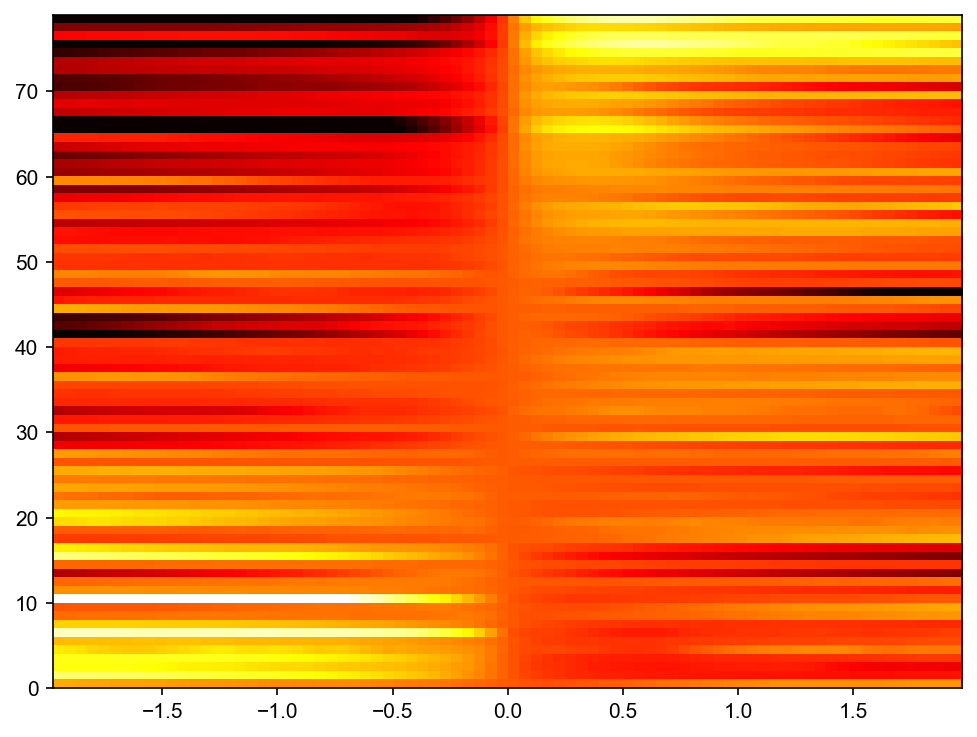

In [12]:
plt.imshow(
    sta[:, order].d.T,
    aspect='auto',
    origin='lower',
    extent=[sta.index[0], sta.index[-1], 0, sta.shape[1]],
    cmap='hot',
    norm=norm,
    )

In [4]:
mouse_id = MOUSE_IDS[0]
turn_units      = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "turn_units.npz")
head_direction  = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "head_direction.npz")
sleep           = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "sleep.npz")
sweeps          = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "sweeps.npz")    

In [31]:
values = np.deg2rad(sweeps.d)
times  = sweeps.t
idx = 10

start, end = sweeps.time_support.start[idx], sweeps.time_support.end[idx]
first = np.searchsorted(times, start, side='left')
last  = np.searchsorted(times, end, side='right')
print(first, last)

2027 2141


In [27]:
sweeps.time_support

index    start               end
0        5361.115            5361.46
1        5361.716            5361.875
2        5362.073            5362.2
3        5363.647            5363.872
4        5364.018            5364.277
5        5364.657            5365.027
6        5365.161            5365.191
...      ...                 ...
18038    40883.297999999995  40883.845
18039    40884.669           40884.819
18040    40885.816           40885.901
18041    40886.354           40886.535
18042    40887.108           40887.138999999996
18043    40887.148           40887.247
18044    40887.56            40887.576
shape: (18045, 2), time unit: sec.

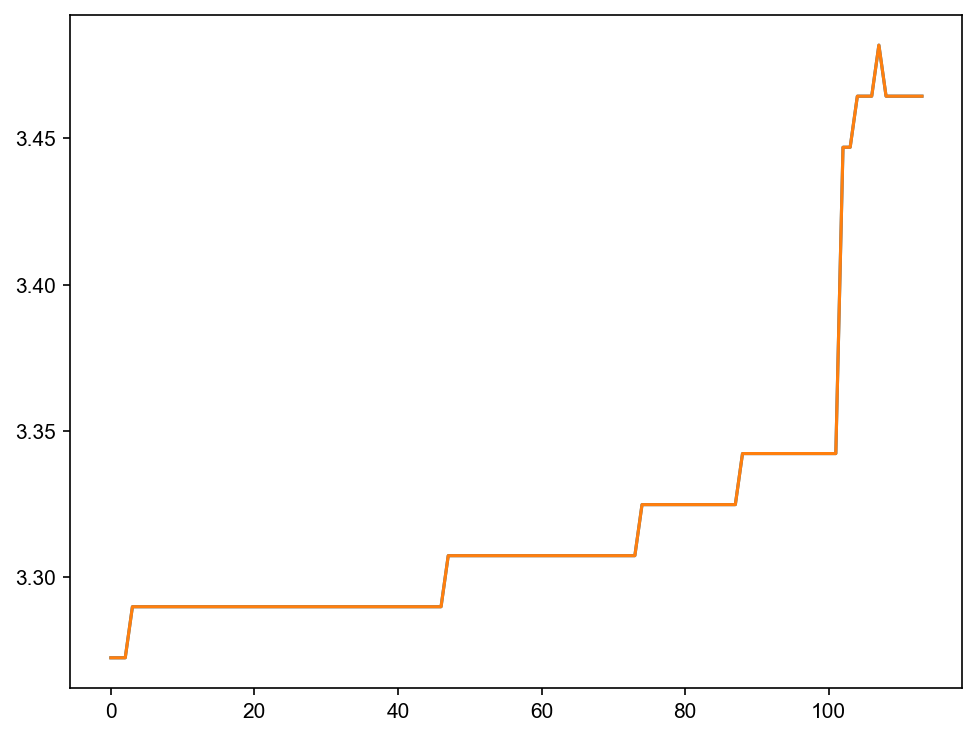

In [32]:
plt.plot(values[first:last])
plt.plot(np.unwrap(values[first:last]))